In [72]:
df = pd.read_csv('sdss_cutout.csv')
df

In [3]:
plt.figure()
redshifts = np.sort(df['Z'].values)
plt.plot(redshifts, np.arange(len(redshifts))/len(redshifts))
plt.title('Empirical CDF')
plt.ylabel('Number of galaxies')
plt.xlabel('redshift')

,RA,DEC,Z,phot_u,phot_g,phot_r,phot_i,phot_z
0,130.089951,52.178097,0.097629,19.854843,18.159964,17.345013,16.930433,16.620535
1,130.173909,52.557767,0.067737,19.250399,17.239248,16.517265,16.083832,15.822161
2,130.081237,52.668188,0.063350,18.680342,17.206959,16.697826,16.362032,16.173033
3,130.291706,52.572373,0.065425,19.726742,17.791235,16.906610,16.495539,16.182104
4,130.013537,52.766588,0.123360,19.386818,17.534359,16.450377,15.943369,15.545097
...,...,...,...,...,...,...,...,...
319953,149.580633,47.033396,0.390038,23.223936,19.346468,17.534588,16.857544,16.351515
319954,150.261929,46.827647,0.204686,20.360432,18.511255,17.276648,16.812563,16.496658
319955,149.937963,46.482358,0.102099,19.087252,17.185118,16.237055,15.844631,15.480799
319956,150.023597,46.260926,0.069142,19.072407,17.949339,17.497790,17.227016,17.132250


In [ ]:
data_cut = df[(df['Z'] > 0.08) & (df['Z'] < 0.12)].copy()

## Task 2

Text(0, 0.5, 'phot_r')

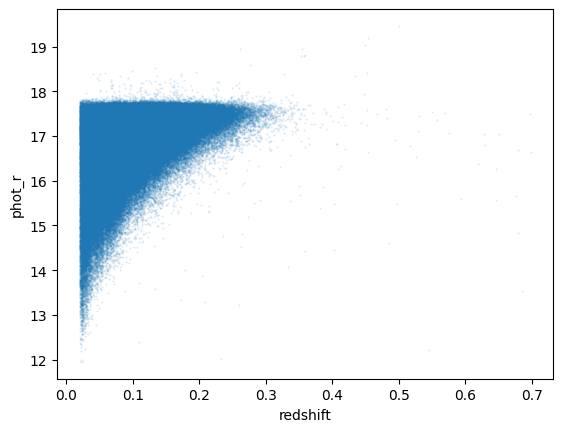

In [5]:
data_cut['u-r'] = data_cut['phot_u'] - data_cut['phot_r']

## Task 3

Text(0, 0.5, 'phot_r')

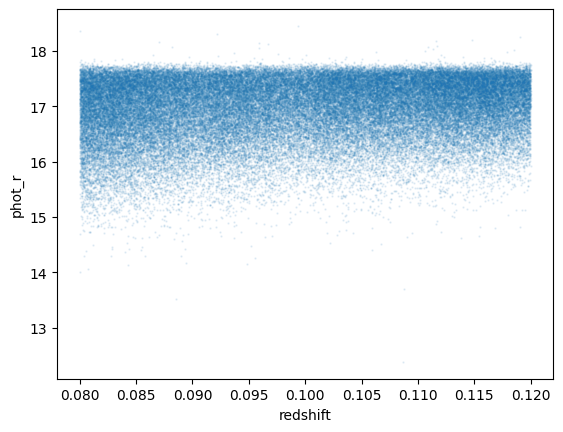

In [7]:
# sp.stats.bootstrap((red['phot_r'].to_numpy(),), np.mean, vectorized=False, n_resamples=1000, confidence_level=0.95, method='percentile')

In [ ]:
def z_alpha(a):
    return sp.stats.norm.ppf((1+a)/2)

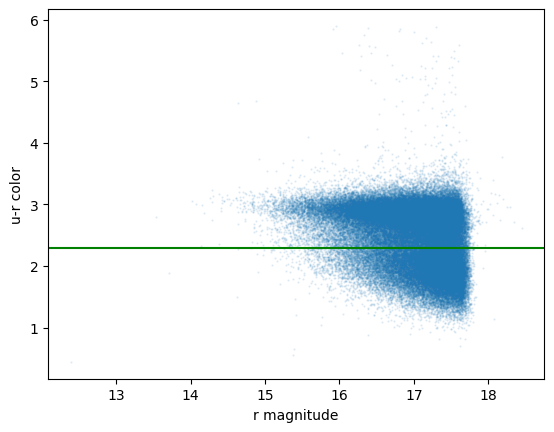

In [8]:
print(conf_interval)
print(conf_interval/z_alpha(0.95))
print(np.mean(red['phot_r'])-conf_interval, np.mean(red['phot_r'])+conf_interval)

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 15), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax[0].gridlines()
ax[0].scatter(red['RA'], red['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

ax[1].gridlines()
ax[1].scatter(blue['RA'], blue['DEC'], s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='blue')


## Task 5. Computing the two-point correlation function

Uniform distribution on the cartesian ra/dec grid is not uniform on the sphere. To demonstrate this we created a function which can generate uniformly distributed objects either on cartesian grid or on sperical grid.

We followed this method of generating uniform distribution on spere: https://github.com/CorySimon/CorySimon.github.io/blob/master/_posts/articles/2015-02-27-uniformdistn-on-sphere.md

Changes we made:
1) Add limits to make it possible to cover just part of the sphere.
2) We work with declination instead of polar angle.

In [12]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg', sphere=False)
fig, ax = plt.subplots(1, 1, figsize=(5, 8), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax.gridlines()
ax.scatter(rand_ra, rand_dec, s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5, 8), subplot_kw={'projection': ccrs.Mollweide(180)},
                        layout='constrained')

ax.gridlines()
ax.scatter(rand_ra, rand_dec, s=0.5, alpha=0.1, transform=ccrs.PlateCarree(), color='red')

### Optimizing pairs counting

In [13]:
@njit(parallel=True)
def spat_corr(x, y, bins):
    n = np.zeros((len(x), len(bins)))
    for i in prange(len(x)):
        for j in range(len(y)):
            sep = dist_sphere(x[i], y[j])
            for k, b in enumerate(bins):
                if sep < b:
                    n[i, k] = n[i, k] + 1
                    break
    return np.sum(n, axis=0)

@njit(parallel=True)
def spat_spec(x, bins):
    n = np.zeros((len(x), len(bins)))
    for i in prange(len(x)):
        for j in range(i+1, len(x)):
            sep = dist_sphere(x[i], x[j])
            for k, b in enumerate(bins):
                if sep < b:
                    n[i, k] = n[i, k] + 1
                    break
    return np.sum(n, axis=0)

@njit()
def dist_cart(first, second):
    return np.sqrt((first[0]-second[0])**2 + (first[1]-second[1])**2)

@njit()
def dist_sphere(A, B):
    """
    assumes that every coordinate is [RA(rad), DEC(rad)]
    """
    cos_theta = np.sin(A[1])*np.sin(B[1]) + np.cos(A[1])*np.cos(B[1])*np.cos(A[0]-B[0])
    return np.arccos(cos_theta)

In [14]:
def tp_corr_func_LS(points, bins, M=None, rand_field=None, RR_=None):
    """
    points: ndarray
        2D array, each row is ra-dec coordinate (in rad)
    bins: ndarray
        distance bins for 2D-correlation func
    M: None or int, optional, default=None
        number of points in uniform distribution
    """
    N = len(points)
    # N if M is None, else M
    M = M or N
    if rand_field is None:
        ra_min, dec_min = np.min(points, axis=0)
        ra_max, dec_max = np.max(points, axis=0)
        rand_ra_, rand_dec_ = unirand_field(ra_min, ra_max, dec_min, dec_max, M)
        rand_field = np.array([rand_ra_, rand_dec_]).T
    if RR_ is None:
        RR_ = spat_spec(rand_field, bins)
    DD = spat_spec(points, bins)
    RD = spat_corr(rand_field, points, bins)

    corr = 1 + M*(M-1)*DD/(N*(N-1)*RR_) - (M-1)*RD/(N*RR_)
    return corr 

0.0044026743807326785
0.00224630371550723
16.88049945851626 16.889304807277725


In [ ]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg')
general_rand_field = np.array([rand_ra, rand_dec]).T * np.pi/180.
RR = spat_spec(general_rand_field, ang_bins)

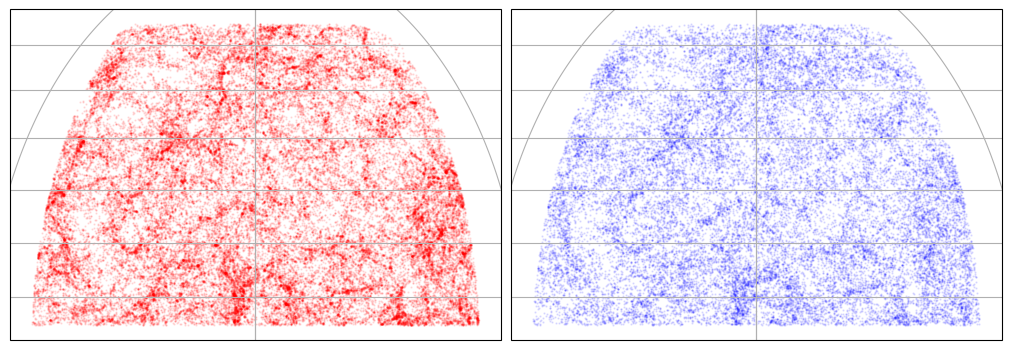

In [15]:
blue_np = np.array([blue['RA'].values, blue['DEC'].values]).T * np.pi/180.

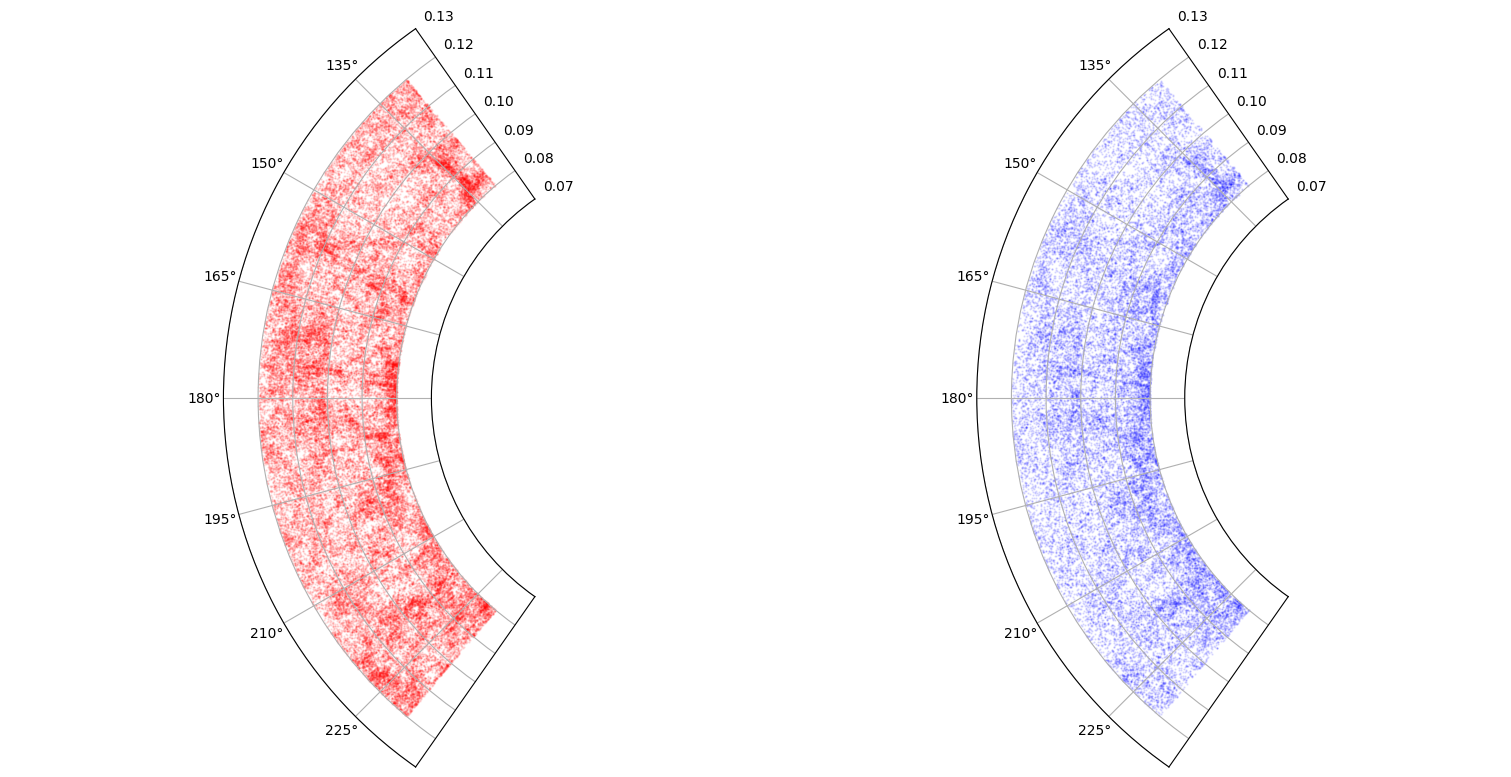

In [16]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_red, 'ro', label='red galaxies')
ax.plot(ang_bins, corr_blue, 'bo', label='blue galaxies')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("$\\Theta$")
ax.set_ylabel("$\\hat \\xi (\\Theta)$")

In [ ]:
corr_red_j, corr_red_err, _ = jacknife(red_np, tp_corr_func_LS, sub_n=5000, args=(ang_bins,), itn=25, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [ ]:
corr_blue_j, corr_blue_err, jackknife_blue = jacknife(blue_np, tp_corr_func_LS, sub_n=5000, args=(ang_bins,), itn=25, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [ ]:
fig, ax = plt.subplots()

ax.errorbar(ang_bins, corr_red, yerr=corr_red_err, color='red')
ax.errorbar(ang_bins, corr_blue, yerr=corr_blue_err, color='blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("$\\Theta$")
ax.set_ylabel("$\\hat \\xi (\\Theta)$")

In [ ]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

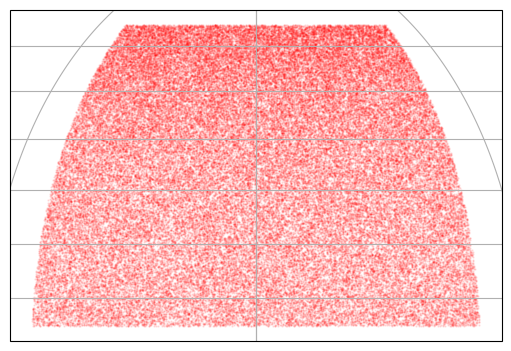

In [19]:
rand_ra, rand_dec = unirand_field(130, 230, 5, 65, len(data_cut), unit='deg', sphere=True)

In [20]:
general_rand_field = np.array([rand_ra, rand_dec]).T * np.pi/180.

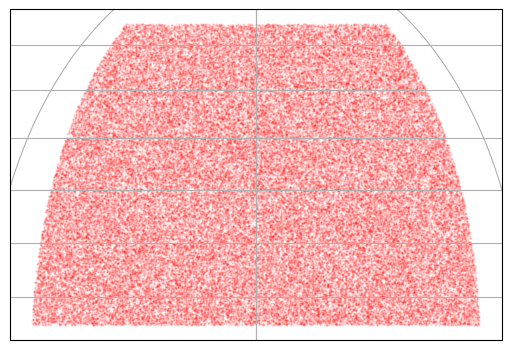

In [21]:
ang_bins = np.geomspace(0.003,0.3,11)

In [22]:
rng = np.random.default_rng()
small_subset = rng.choice(general_rand_field, 10, replace=False)

spat_corr(small_subset, small_subset, ang_bins)
spat_spec(small_subset, ang_bins)

In [ ]:
red_np = np.array([red['RA'].values, red['DEC'].values]).T * np.pi/180.

In [23]:
corr_red = tp_corr_func_LS(red_np, ang_bins, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [24]:
corr_blue = tp_corr_func_LS(blue_np, ang_bins, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [25]:
def jacknife(data, statistics, sub_n=None, itn=10, args=(), **kwargs):
    rng_ = np.random.default_rng()
    N = len(data)
    sub_n = sub_n or N/10

    if not isinstance(sub_n, int):
        try:
            sub_n = int(sub_n)
        except ValueError:
            print("Number of elements in subsample should be integer!")

    if sub_n > N:
        raise ValueError("Subsample should be smaller than full sample!")
            
    if not isinstance(args, tuple):
        args = (args,)
        
    res = []
    for _ in tqdm(range(itn)):
        subsample = rng_.choice(data, sub_n, replace=False)
        res.append(statistics(subsample, *args, **kwargs))
    raw_var = np.var(res, ddof=1, axis=0)
    sigma = np.sqrt(raw_var)
    av = np.mean(res, axis=0)
    return av, sigma, res

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 3., 4.])

In [26]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_red, 'o')

ax.errorbar(ang_bins, corr_red_j, yerr=corr_red_err)
ax.set_xscale('log')
ax.set_yscale('log')

In [27]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=corr_blue_err)
ax.set_xscale('log')
ax.set_yscale('log')

In [28]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

In [29]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

In [30]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

In [31]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_red, 'ro', label='red galaxies')
ax.plot(ang_bins, corr_blue, 'bo', label='blue galaxies')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("$\\Theta$")
ax.set_ylabel("$\\hat \\xi (\\Theta)$")

Text(0, 0.5, '$\\hat \\xi (\\Theta)$')

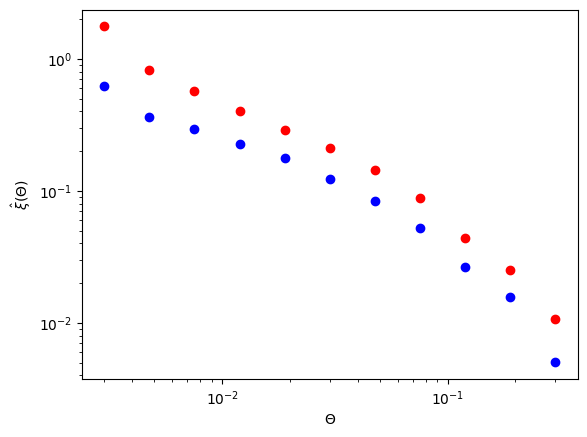

In [81]:
corr_red_j, corr_red_err, _ = jacknife(red_np, tp_corr_func_LS, sub_n=5000, args=(ang_bins,), itn=25, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [33]:
corr_blue_j, corr_blue_err, jackknife_blue = jacknife(blue_np, tp_corr_func_LS, sub_n=5000, args=(ang_bins,), itn=25, M=len(general_rand_field), rand_field=general_rand_field, RR_=RR)

In [51]:
fig, ax = plt.subplots()

ax.errorbar(ang_bins, corr_red, yerr=corr_red_err, color='red')
ax.errorbar(ang_bins, corr_blue, yerr=corr_blue_err, color='blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("$\\Theta$")
ax.set_ylabel("$\\hat \\xi (\\Theta)$")

100%|███████████████████████████████████████████| 25/25 [03:39<00:00,  8.76s/it]


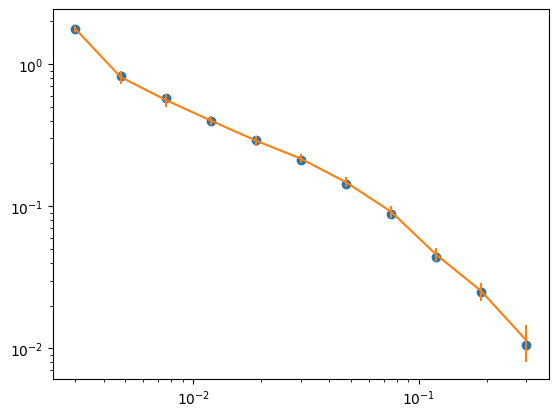

In [49]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

100%|███████████████████████████████████████████| 25/25 [03:31<00:00,  8.46s/it]


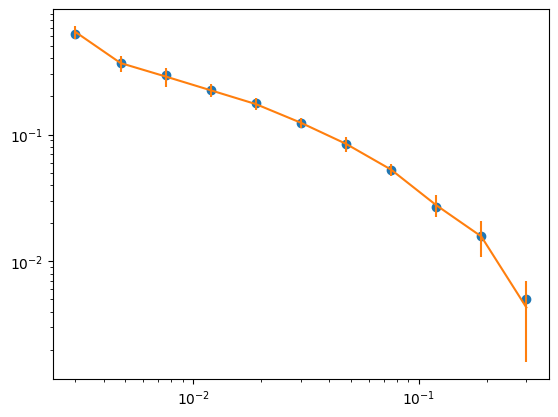

Text(0, 0.5, '$\\hat \\xi (\\Theta)$')

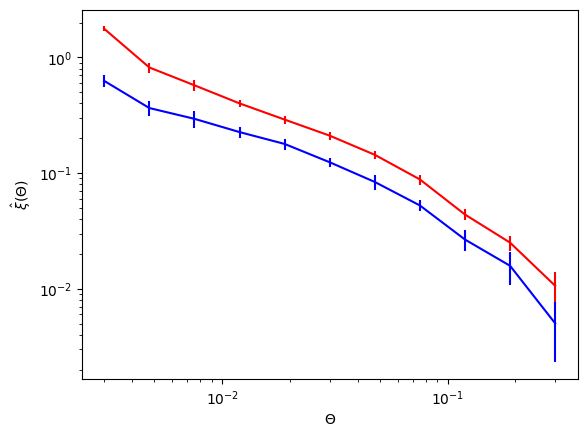

In [80]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

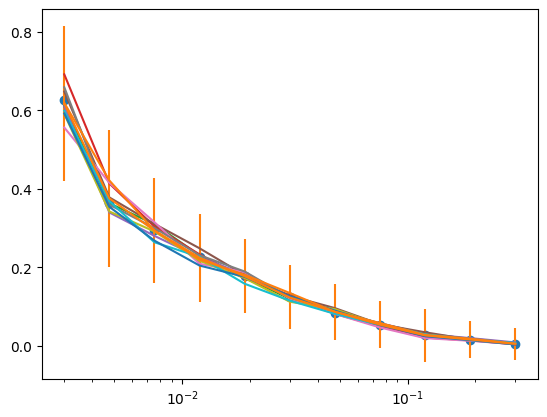

In [43]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

In [ ]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')

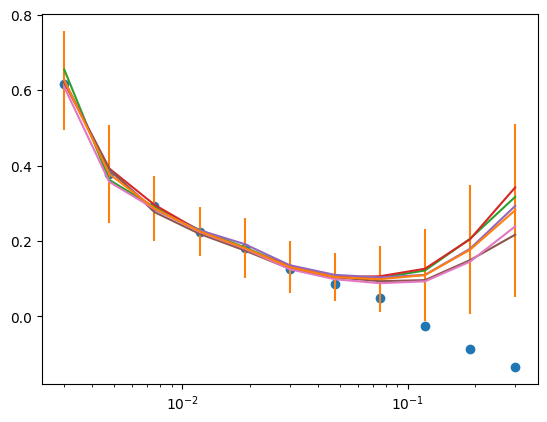

In [53]:
fig, ax = plt.subplots()
ax.plot(ang_bins, corr_blue, 'o')
ax.errorbar(ang_bins, corr_blue_j, yerr=np.sqrt(corr_blue_err))
ax.set_xscale('log')
for jk in jackknife_blue:
    ax.plot(ang_bins, jk)
    ax.set_xscale('log')